In [1]:
import pyarrow.parquet as pq
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Data analysis of the articles.parquet file

### Import

In [2]:
path = os.path.join('datas', 'ebnerd_demo', 'articles.parquet')
print(path)
articles = pq.read_table(path).to_pandas()
articles.info()

datas/ebnerd_demo/articles.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11777 entries, 0 to 11776
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   article_id          11777 non-null  int32         
 1   title               11777 non-null  object        
 2   subtitle            11777 non-null  object        
 3   last_modified_time  11777 non-null  datetime64[us]
 4   premium             11777 non-null  bool          
 5   body                11777 non-null  object        
 6   published_time      11777 non-null  datetime64[us]
 7   image_ids           10840 non-null  object        
 8   article_type        11777 non-null  object        
 9   url                 11777 non-null  object        
 10  ner_clusters        11777 non-null  object        
 11  entity_groups       11777 non-null  object        
 12  topics              11777 non-null  object        
 13  category   

### NaN analysis
NaN ratio for every variables :

In [7]:
articles.isna().sum()/len(articles)

article_id            0.000000
title                 0.000000
subtitle              0.000000
last_modified_time    0.000000
premium               0.000000
body                  0.000000
published_time        0.000000
image_ids             0.079562
article_type          0.000000
url                   0.000000
ner_clusters          0.000000
entity_groups         0.000000
topics                0.000000
category              0.000000
subcategory           0.000000
category_str          0.000000
total_inviews         0.362656
total_pageviews       0.362656
total_read_time       0.362656
sentiment_score       0.000000
sentiment_label       0.000000
dtype: float64

We see a big proportion of NaN for total_inviews, total_pageviews and total_read_time, this can be explained mostly because "This feature only applies to articles that were published after February 16, 2023.".
This is mostly verified :

In [41]:
published_time_no_total = articles.loc[
    articles[['total_inviews', 'total_pageviews', 'total_read_time']].isna().any(axis=1), 
    'published_time'
]

published_time_no_total[published_time_no_total < '2023-02-16'].count()/len(published_time_no_total)

0.9957934096751577

In [8]:
articles.loc[:,['total_inviews','total_pageviews','total_read_time']].isna().any(axis=1).sum()

4279

Let's learn more about the repartition : 

### Total Inviews 
*The total number of times an article has been inview (registered as seen) by users within the first 7 days after it was published. This feature only applies to articles that were published after February 16, 2023.*

In [15]:
articles.loc[:,'total_inviews'].isna().sum()

4271

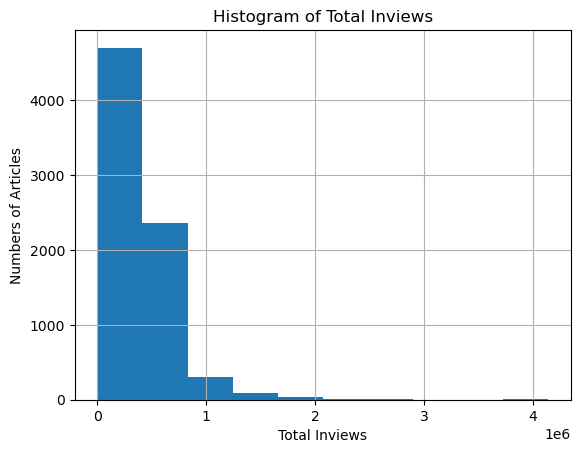

In [16]:
total_inviews_df = articles.loc[:,'total_inviews'].dropna()
total_inviews_df.hist()
plt.xlabel('Total Inviews')
plt.ylabel('Numbers of Articles')
plt.title('Histogram of Total Inviews')
plt.show()

### Total pageviews
*The total number of times an article has been clicked by users within the first 7 days after it was published. This feature only applies to articles that were published after February 16, 2023.*

In [18]:
articles.loc[:,'total_pageviews'].isna().sum()

4271

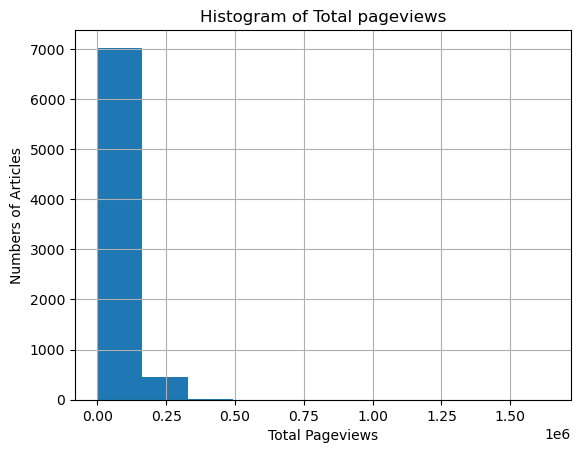

In [19]:
total_pageviews_df = articles.loc[:,'total_pageviews'].dropna()
total_pageviews_df.hist()
plt.xlabel('Total Pageviews')
plt.ylabel('Numbers of Articles')
plt.title('Histogram of Total pageviews')
plt.show()

### Total Read Time
*The accumulated read time of an article within the first 7 days after it was published. This feature only applies to articles that were published after February 16, 2023.*

In [21]:
articles.loc[:,'total_read_time'].isna().sum()

4271

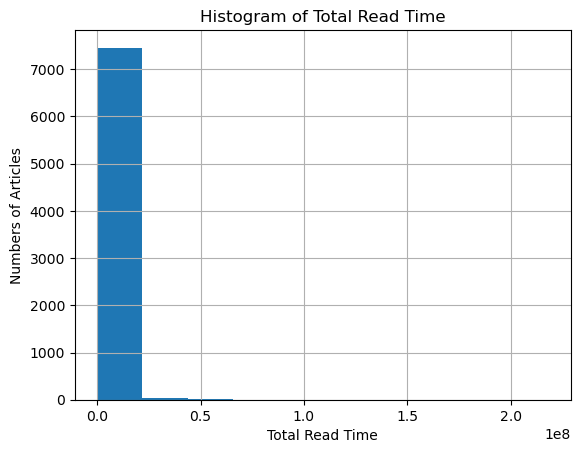

In [23]:
total_read_time_df = articles.loc[:,'total_read_time'].dropna()
total_read_time_df.hist()
plt.xlabel('Total Read Time')
plt.ylabel('Numbers of Articles')
plt.title('Histogram of Total Read Time')
plt.show()

By showing the historigram of total inviews, pageviews and read time we learn that a lot of articles are not considered at all.
This means we need to take this into consideration for the evaluation, as a recommander system that predict every articles not to be seen would have a good score.

### Premium
*Whether the content is behind a paywall.*

In [29]:
articles.loc[:,'premium'].value_counts()

premium
False    7877
True     3900
Name: count, dtype: int64

This data is quite important to take into consideration, that's why we should compute the recommendation of the premium users separately.
It is also confirmed with the very low total inviews of such articles.

In [48]:
premium_articles_total_inviews_df = articles.loc[articles['premium'] == True, 'total_inviews']
premium_articles_total_inviews_df.isna().sum()

3139

<Axes: >

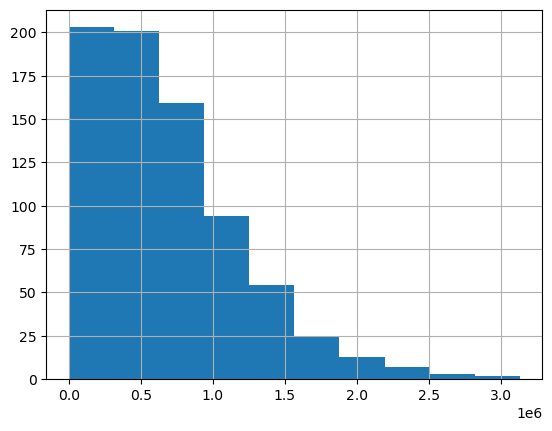

In [49]:
premium_articles_total_inviews_df.hist()

### Category (Category ID, Category string, Subcategory IDs)
*The category ID., The category as a string., The subcategory IDs.*


In [50]:
articles.loc[:, 'category'].value_counts()

category
118     2736
142     2146
414     1775
140     1566
572      869
457      826
2889     612
565      463
512      286
498      181
2975     121
539       51
529       32
561       27
2077      24
68        21
22        11
2          8
2341       7
806        5
1505       4
2737       3
2731       2
731        1
Name: count, dtype: int64

In [ ]:
articles.loc[:, 'subcategory'].value_counts()


subcategory
[133]    1212
[425]     541
[475]     491
[127]     358
[432]     355
         ... 
[]          1
[]          1
[]          1
[]          1
[]          1
Name: count, Length: 6389, dtype: int64

In [ ]:
articles.loc[:, 'category_str'].value_counts()

category_str
nyheder             2733
sport               2146
underholdning       1775
krimi               1566
side9                869
forbrug              826
auto                 612
sex_og_samliv        463
nationen             286
musik                181
penge                121
ferie                 51
biler                 32
haandvaerkeren        27
opinionen             24
play                  21
horoskoper            11
incoming               8
plus                   7
om_ekstra_bladet       5
vin                    4
podcast                3
bibliotek              3
dagsorden              2
services               1
Name: count, dtype: int64

### Ner clusters
*The tags retrieved from a proprietary named-entity-recognition model at Ekstra Bladet are based on the concatenated title, abstract, and body.*

In [57]:
articles.loc[:, 'ner_clusters'].value_counts()

ner_clusters
[København]                                                                                                                                                                                                                                                                            53
[Casper Sobczyk]                                                                                                                                                                                                                                                                       20
[Ekstra Bladet]                                                                                                                                                                                                                                                                        20
[Herlev]                                                                                                                                     

### Topics
*The tags retrieved from a proprietary topic-recognition model at Ekstra Bladet are based on the concatenated title, abstract, and body.*

In [56]:
articles.loc[:, 'topics'].value_counts()

topics
[Livsstil]                                                    208
[Kriminalitet]                                                109
[Dyr]                                                          53
[Vejr]                                                         47
[Begivenhed]                                                   26
                                                             ... 
[Livsstil, Sundhed, Sygdom og behandling, Krop og velvære]      1
[Begivenhed, Sport, Sportsbegivenhed, Håndbold]                 1
[Kultur, Museum og seværdighed]                                 1
[Livsstil, Erotik]                                              1
[Kriminalitet, Bedrageri]                                       1
Name: count, Length: 11269, dtype: int64

### Sentiment score
*The sentiment score from a proprietary sentiment model at Ekstra Bladet is based on the concatenated title and abstract.*

<Axes: >

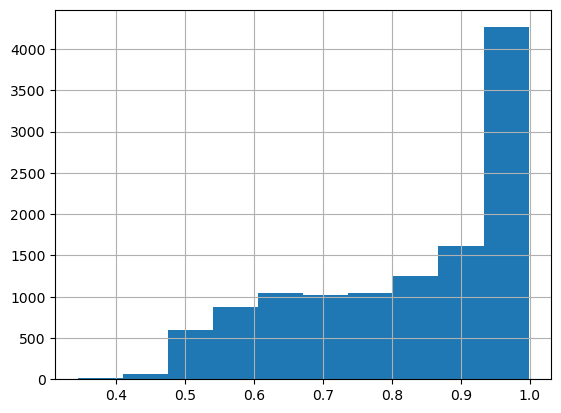

In [54]:
articles.loc[:, 'sentiment_score'].hist()

### Sentiment label
*The assigned sentiment label from a proprietary sentiment model at Ekstra Bladet is based on the concatenated title and abstract. The labels are positive, neutral, and negative.*

In [58]:
articles.loc[:, 'sentiment_label'].value_counts()

sentiment_label
Negative    5004
Neutral     4793
Positive    1980
Name: count, dtype: int64

## Variables relations analysis

### Correlation matrix
Corr matrix of the quantitative values total_inviews, total_pageviews, total_read_time, sentiment_score, category.

<Axes: >

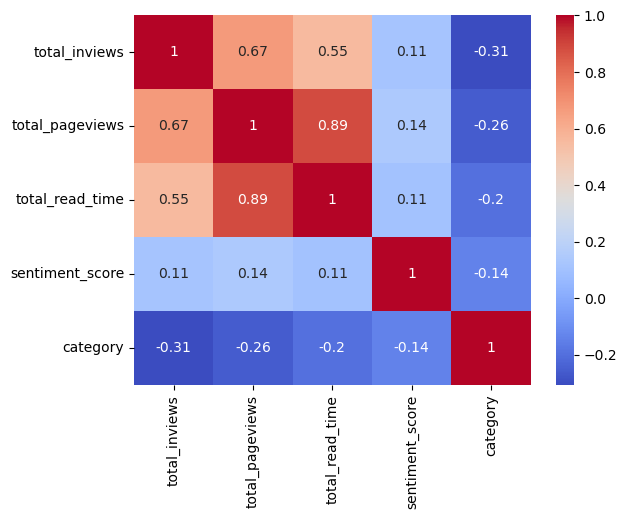

In [69]:
quantitative_values_df = articles.loc[:,['total_inviews','total_pageviews','total_read_time','sentiment_score','category']].dropna()
sns.heatmap(quantitative_values_df.corr(), cmap='coolwarm', annot=True)

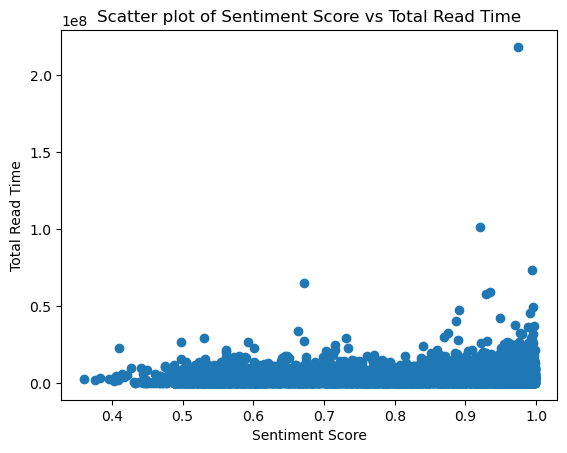

In [74]:
plt.scatter(quantitative_values_df.loc[:,'sentiment_score'], quantitative_values_df.loc[:,'total_read_time'])
plt.xlabel('Sentiment Score')
plt.ylabel('Total Read Time')
plt.title('Scatter plot of Sentiment Score vs Total Read Time')
plt.show()

### PCA

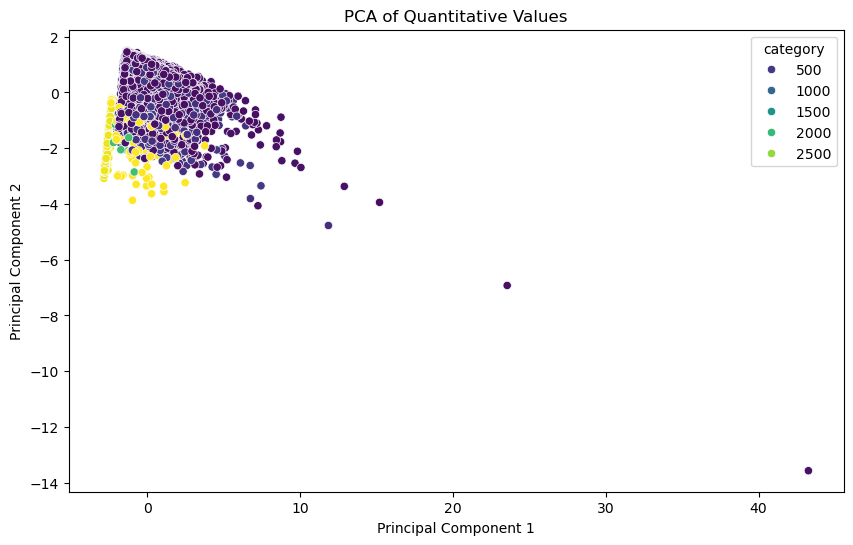

In [78]:
# Standardize the data
scaler = StandardScaler()
quantitative_values_scaled = scaler.fit_transform(quantitative_values_df)

# Perform PCA
pca = PCA(n_components=2)  # You can change the number of components as needed
principal_components = pca.fit_transform(quantitative_values_scaled)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Add the category column back to the DataFrame for visualization
pca_df['category'] = quantitative_values_df['category'].values

# Plot the PCA result
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='category', data=pca_df, palette='viridis')
plt.title('PCA of Quantitative Values')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()